In [1]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

import privugger as pv

In [2]:
np.repeat(50,10).sum().item()

500

In [ ]:
import os

def program_sum(x):
    return np.array(x.sum())

pv.reset()

# Database size
N    = 10

# Specify distributions
age  = pv.Binomial("age", p=0.5, n=100, num_elements=N)

# Create dataset. Refer to "age_alice" as "age1" in the trace and "age" as "age2" in the trace. This is the general naming convention. 
ds   = pv.Dataset(input_specs = [age])

# For now output type can be: Int, Float, List(Float), List(Int)
program = pv.Program("output", dataset=ds, output_type=pv.Int, function=program_sum)

# Add observations
observed_output = 500
program.add_observation(f"output=={observed_output}", precision=0)

# Call infer and specify program output
trace = pv.infer(program, cores=2, draws=1000, initvals={'age': [50,50,50,50,50,50,50,50,50,50]})
os.remove("typed.py")



SamplingError: Initial evaluation of model at starting point failed!
Starting values:
{'age': array([50, 50, 50, 50, 50, 50, 50, 50, 50, 10])}

Logp initial evaluation results:
{'age': -61.61, 'cons_1': -inf}
You can call `model.debug()` for more details.

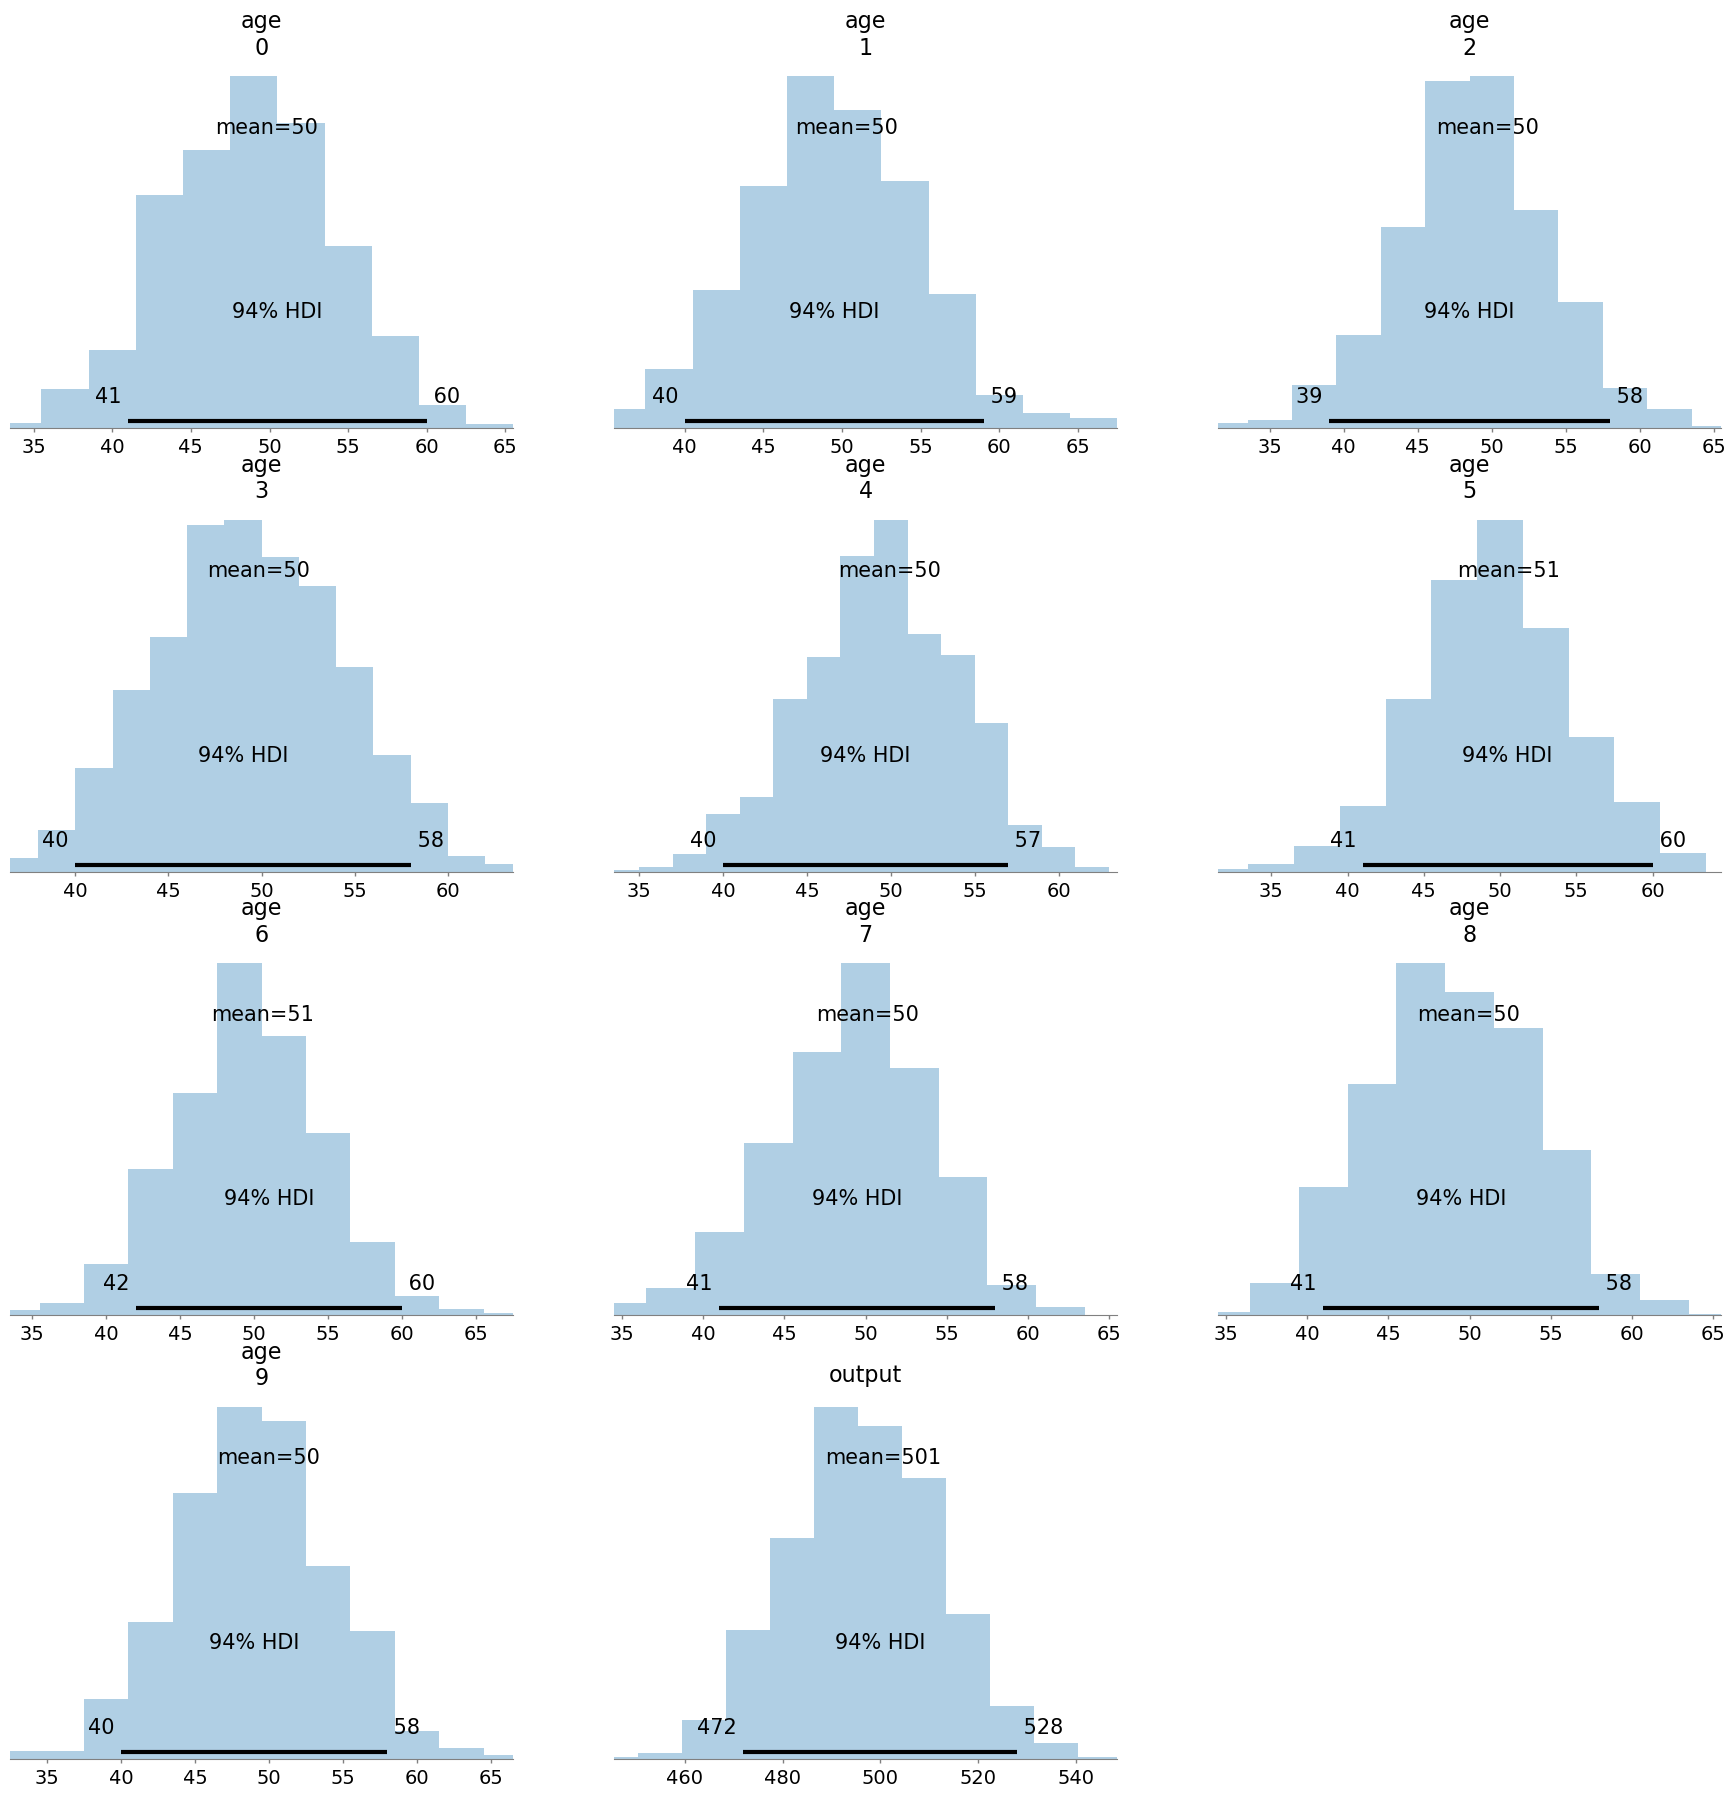

In [ ]:
az.plot_posterior(trace);

## Data

The Gowalla dataset below can be downloaded from: https://snap.stanford.edu/data/loc-gowalla.html

In [ ]:
df_gow = pd.read_csv('loc-gowalla_totalCheckins.txt.gz', nrows=10000, compression='gzip', sep="	", 
                     names=['user','check-in_time','latitude','longitude','location_id'])

In [ ]:
df_gow

,user,check-in_time,latitude,longitude,location_id
0,0,2010-10-19T23:55:27Z,30.235909,-97.795140,22847
1,0,2010-10-18T22:17:43Z,30.269103,-97.749395,420315
2,0,2010-10-17T23:42:03Z,30.255731,-97.763386,316637
3,0,2010-10-17T19:26:05Z,30.263418,-97.757597,16516
4,0,2010-10-16T18:50:42Z,30.274292,-97.740523,5535878
...,...,...,...,...,...
9995,53,2010-09-18T19:51:26Z,37.764758,-122.508696,382725
9996,53,2010-09-18T19:51:06Z,37.763966,-122.510259,1589472
9997,53,2010-09-18T19:36:08Z,37.783179,-122.464356,1787396
9998,53,2010-09-18T18:46:18Z,37.782851,-122.464685,9867


In [ ]:
df_gow['location_id_codes'] = df_gow.location_id.astype('category').cat.codes

In [ ]:
num_locs = df_gow.location_id.unique().size

In [ ]:
df_gow[df_gow.user == 0].groupby(['user', 'location_id']).count().to_xarray()

<xarray.Dataset> Size: 5kB
Dimensions:            (user: 1, location_id: 135)
Coordinates:
  * user               (user) int64 8B 0
  * location_id        (location_id) int64 1kB 8938 8964 ... 4256132 5535878
Data variables:
    check-in_time      (user, location_id) int64 1kB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    latitude           (user, location_id) int64 1kB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    longitude          (user, location_id) int64 1kB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    location_id_codes  (user, location_id) int64 1kB 1 1 1 1 1 1 ... 1 1 1 1 1 1

In [ ]:
df_gow[df_gow.user == 0].location_id.value_counts()

location_id
420315     28
21714      14
18417       7
480992      6
1221889     4
           ..
15590       1
539065      1
211286      1
4256132     1
608105      1
Name: count, Length: 135, dtype: int64

In [ ]:
df_gow[df_gow.location_id == 420315]

,user,check-in_time,latitude,longitude,location_id,location_id_codes
1,0,2010-10-18T22:17:43Z,30.269103,-97.749395,420315,4149
7,0,2010-10-12T19:44:40Z,30.269103,-97.749395,420315,4149
9,0,2010-10-12T15:19:03Z,30.269103,-97.749395,420315,4149
37,0,2010-10-06T23:25:34Z,30.269103,-97.749395,420315,4149
40,0,2010-10-05T16:10:35Z,30.269103,-97.749395,420315,4149
...,...,...,...,...,...,...
9528,52,2010-07-13T18:39:58Z,30.269103,-97.749395,420315,4149
9533,52,2010-07-09T23:14:55Z,30.269103,-97.749395,420315,4149
9535,52,2010-07-08T22:20:09Z,30.269103,-97.749395,420315,4149
9543,52,2010-07-02T23:06:32Z,30.269103,-97.749395,420315,4149


## Privugger model

In [ ]:
np.repeat(1/num_locs, num_locs)

array([0.00015288, 0.00015288, 0.00015288, ..., 0.00015288, 0.00015288,
       0.00015288])

In [ ]:
# input spec
NLOCS = 30 # we consider NLOCS locations per user
# `num_locs` contains the total number of locations in the detaset; it is bind above

def zn_uniform(p_zero, n):
    return [p_zero] + [(1-p_zero)/n]*n

raw_loc   = pv.Categorical("raw_loc", p=list(np.repeat(1/num_locs, num_locs)), num_elements=(NLOCS))
anonymize = pv.Categorical("anonymize", p=zn_uniform(.99, num_locs-1), num_elements=(NLOCS))

### Anonymization program

In [ ]:
def loc_anonymisation(locs, anonymize):
    NLOCS = 30 # copied from above, due to type error cannot be added as a parameter
    for i in range(0, NLOCS):
        if anonymize[i] != 0:
            locs[i] = anonymize[i]
    return locs

In [ ]:
ds = pv.Dataset(input_specs=[raw_loc, anonymize])

In [ ]:
program = pv.Program('output',
                     dataset=ds,
                     output_type=pv.List(pv.Int),
                     function=loc_anonymisation)

In [ ]:
obs = list(df_gow[df_gow.user == 0].location_id_codes.values[:NLOCS])

In [ ]:
program.add_observation(f'output=={obs}', precision=0)

In [ ]:
trace = pv.infer(program, cores=4, draws=10000, method='pymc3', return_model=False, initvals={'raw_loc': obs})

Multiprocess sampling (2 chains in 2 jobs)
CategoricalGibbsMetropolis: [raw_loc, anonymize]


Output()

Sampling 2 chains for 1_000 tune and 10_000 draw iterations (2_000 + 20_000 draws total) took 54 seconds.
/home/pardo/programs/miniconda3/envs/privugger/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
We recommend running at least 4 chains for robust computation of convergence diagnostics


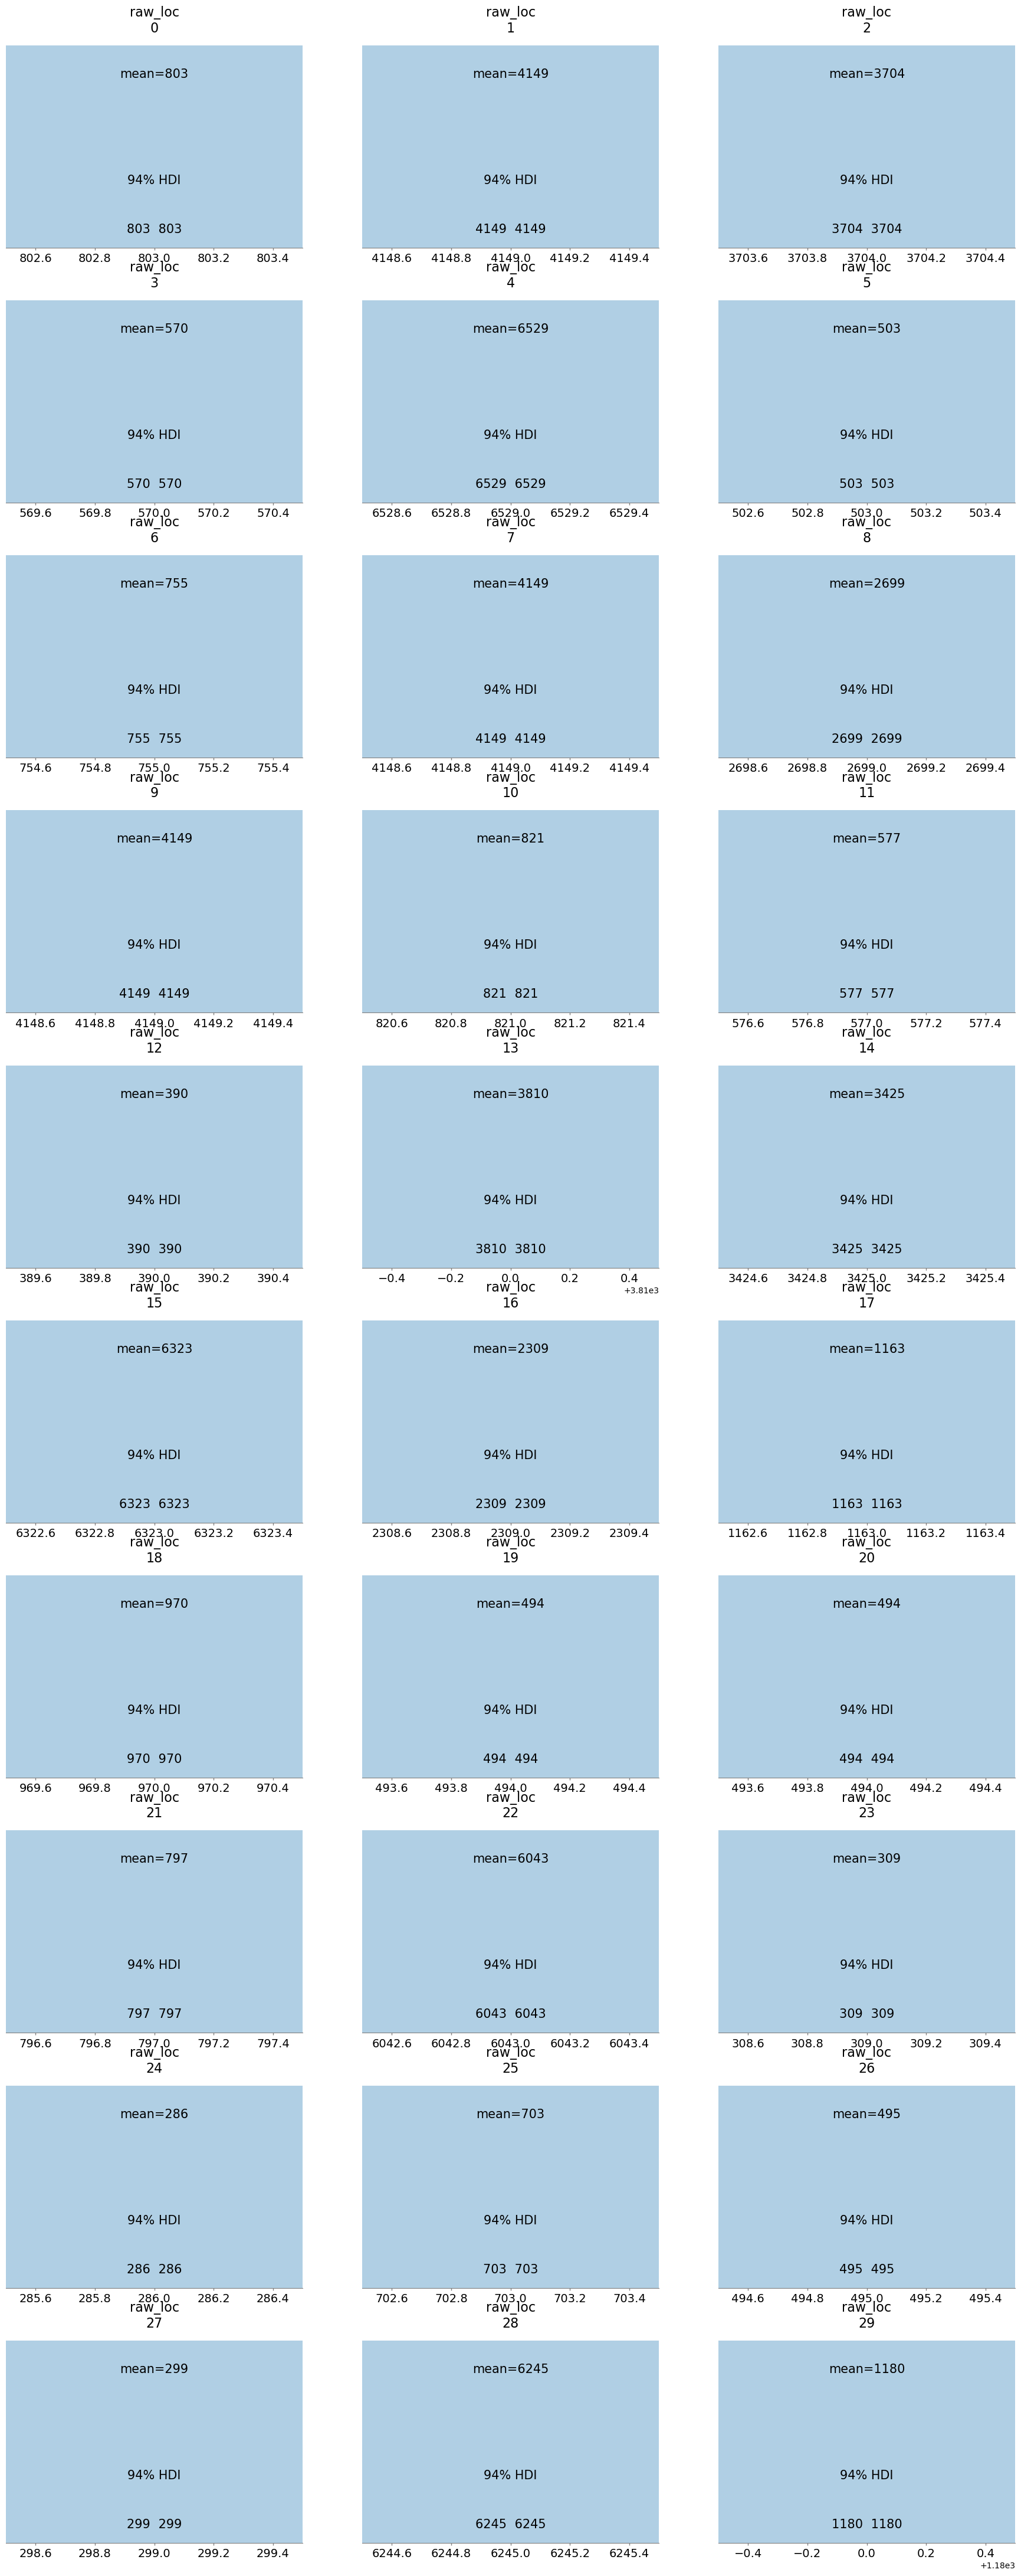

In [ ]:
az.plot_posterior(trace,var_names=['raw_loc']);

/tmp/ipykernel_417342/2293715797.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(similarity, ax=ax)


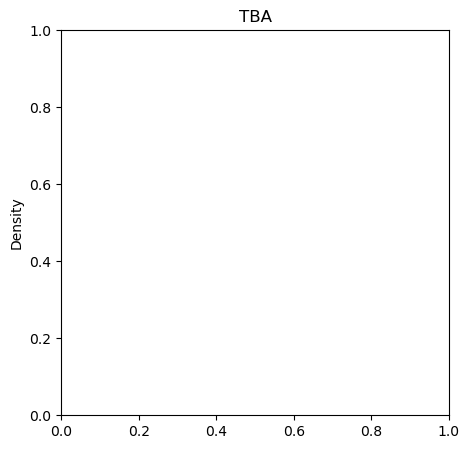

In [ ]:
from numpy.linalg import norm
import seaborn as sns

def cos_sim(a, b):
    return np.dot(a, b)/(norm(a)*norm(b))

def plot_sim(trace, ax, title):
    nlocs = trace.posterior["raw_loc"].values.shape[-1]
    posterior = trace.posterior["raw_loc"].values.reshape([-1, nlocs])
    similarity = list(map(lambda b: cos_sim(obs[:nlocs], b), posterior))
    ax.set_title(title)
    sns.kdeplot(similarity, ax=ax)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_sim(trace, ax, "TBA")

50.0


<BarContainer object of 100 artists>

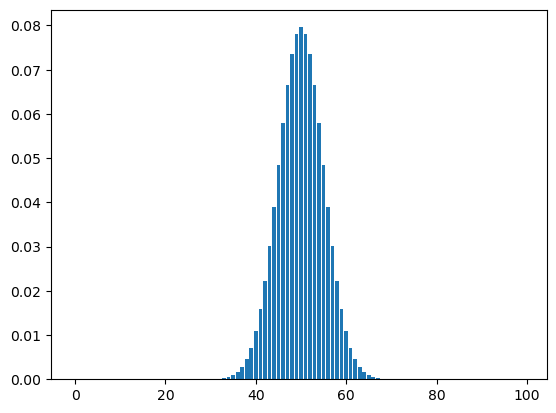

In [ ]:
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt

p = 0.5
N = 100
print(p*N)
x = np.arange(0,100,step=1)
plt.bar(x, binom(p=p, n=N).pmf(x))